# 강원특별자치도_통신판매업.csv

In [81]:
import os
import pandas as pd
base_dir = os.getcwd()
file_path = os.path.join(base_dir,'data_csv', '강원특별자치도_통신판매업.csv')
if not os.path.exists(file_path):
    print("경로에 파일이 존재하지 않습니다. 폴더 이름이나 파일명이 정확한지 확인하세요.")
else:
    try:
        data = pd.read_csv(file_path,encoding = 'cp949', low_memory= False)
        data_columns = list(data.columns)
        print('encoding제대로 하였습니다.')
    except UnicodeDecodeError:
        print("\n⚠️ CP949 인코딩 오류 발생! UTF-8로 다시 시도합니다.")
        data = pd.read_csv(file_path, encoding='utf-8', low_memory=False)
        data_columns = list(data.columns)

encoding제대로 하였습니다.


## 1. 컬럼들에 대해 조사하기

## 데이터 info보면 컬럼수 총 32개

In [82]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54073 entries, 0 to 54072
Data columns (total 33 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   번호               54073 non-null  int64  
 1   개방서비스명           54073 non-null  object 
 2   개방서비스아이디         54073 non-null  object 
 3   개방자치단체코드         54073 non-null  int64  
 4   관리번호             54073 non-null  int64  
 5   인허가일자            54073 non-null  object 
 6   인허가취소일자          693 non-null    object 
 7   영업상태구분코드         54073 non-null  int64  
 8   영업상태명            54073 non-null  object 
 9   상세영업상태코드         54073 non-null  int64  
 10  상세영업상태명          54073 non-null  object 
 11  폐업일자             10734 non-null  object 
 12  휴업시작일자           161 non-null    object 
 13  휴업종료일자           161 non-null    object 
 14  재개업일자            58 non-null     object 
 15  소재지전화            15729 non-null  object 
 16  소재지면적            0 non-null      float64
 17  소재지우편번호     

## 2. 데이터가 null인거 찾기 -> 그리고 다 지우기

In [83]:
null_cols = data.columns[data.isnull().all()]
data.drop(columns = null_cols,inplace = True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54073 entries, 0 to 54072
Data columns (total 31 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   번호               54073 non-null  int64  
 1   개방서비스명           54073 non-null  object 
 2   개방서비스아이디         54073 non-null  object 
 3   개방자치단체코드         54073 non-null  int64  
 4   관리번호             54073 non-null  int64  
 5   인허가일자            54073 non-null  object 
 6   인허가취소일자          693 non-null    object 
 7   영업상태구분코드         54073 non-null  int64  
 8   영업상태명            54073 non-null  object 
 9   상세영업상태코드         54073 non-null  int64  
 10  상세영업상태명          54073 non-null  object 
 11  폐업일자             10734 non-null  object 
 12  휴업시작일자           161 non-null    object 
 13  휴업종료일자           161 non-null    object 
 14  재개업일자            58 non-null     object 
 15  소재지전화            15729 non-null  object 
 16  소재지우편번호          5470 non-null   object 
 17  소재지전체주소     

In [84]:
data['폐업일자'].isnull().size

54073

In [85]:
import matplotlib.pyplot as plt
import pandas
plt.rc('font',family = 'Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

In [86]:
import os


통신판매업 폐업 비율 표현

In [87]:
import numpy as np
total_size = data['폐업일자'].size
total_size
def make_autopct_with_count(pct):
    absolute_count = int(np.round(pct*total_size/100))
    return f"{pct:.1f}%\n({absolute_count}명)"

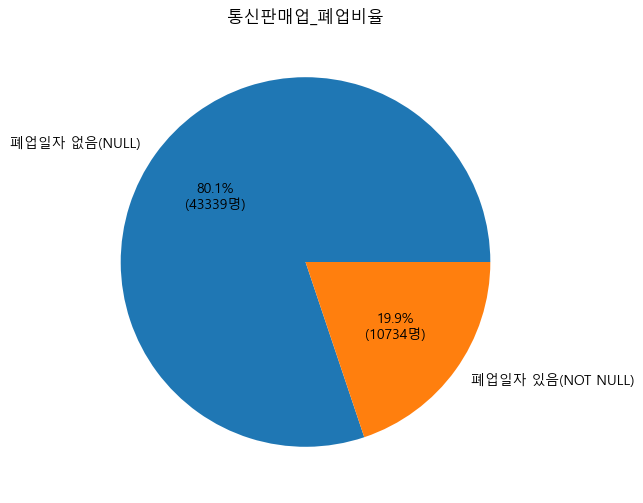

In [88]:
counts = data['폐업일자'].isnull().value_counts()
labels = ['폐업일자 없음(NULL)','폐업일자 있음(NOT NULL)']
sizes = [counts.get(True,0),counts.get(False,0)]
data['폐업일자'].isnull().value_counts()
save_path = os.path.join(os.getcwd(),'data_analysis','통신판매업_폐업차트_png')
plt.figure(figsize = (6,6))
plt.pie(sizes, labels = labels, autopct = make_autopct_with_count)
plt.title('통신판매업_폐업비율')
plt.savefig(save_path,dpi=300,bbox_inches = 'tight')

In [89]:
data.drop(columns = '자본금',inplace = True)

✅ Pandas의 최대 출력 컬럼 수가 '제한 없음(None)'으로 설정되었습니다.
이제 DataFrame을 출력하면 모든 열을 볼 수 있습니다.
